In [2]:
import gpt as g
import numpy as np
import qlat as q
import matplotlib.pyplot as plt
from jackknife import *

SharedMemoryMpi:  World communicator of size 1
SharedMemoryMpi:  Node  communicator of size 1
SharedMemoryMpi: SharedMemoryAllocate 1073741824 MMAP anonymous implementation 

__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|_ |  |  |  |  |  |  |  |  |  |  |  | _|__
__|_                                    _|__
__|_   GGGG    RRRR    III    DDDD      _|__
__|_  G        R   R    I     D   D     _|__
__|_  G        R   R    I     D    D    _|__
__|_  G  GG    RRRR     I     D    D    _|__
__|_  G   G    R  R     I     D   D     _|__
__|_   GGGG    R   R   III    DDDD      _|__
__|_                                    _|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
__|__|__|__|__|__|__|__|__|__|__|__|__|__|__
  |  |  |  |  |  |  |  |  |  |  |  |  |  |  


Copyright (C) 2015 Peter Boyle, Azusa Yamaguchi, Guido Cossu, Antonin Portelli and other authors

This program is free software; you can redistribute it and/or modify
it under the terms of the 

## $\Delta I = 3/2 \ K \rightarrow \pi\pi$ Analysis 

### Load data

In [29]:
dst_kpipi = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-kpipi-Q1Q2-D5/traj-1765/K2pipi_psnk_psrc.lat"

ld_single = q.load_lat_data(dst_kpipi)

arr_single = ld_single.to_numpy()

ld_single.info()[0][2]

['< 1 >  exprs[0]',
 '< wf(0) * pipi_i20(t_1+t_2) * Q1(t_2) * K_0(0)^dag > (ADT1)  exprs[1]',
 '< wf(0) * pipi_i20(t_1+t_2) * Q2(t_2) * K_0(0)^dag > (ADT1)  exprs[2]',
 '< wf(0) * pipi_i00(t_1+t_2) * Q1(t_2) * K_0(0)^dag, Type 1 > (ADT1)  exprs[3]',
 '< wf(0) * pipi_i00(t_1+t_2) * Q1(t_2) * K_0(0)^dag, Type 2 > (ADT2)  exprs[4]',
 '< wf(0) * pipi_i00(t_1+t_2) * Q1(t_2) * K_0(0)^dag, Type 3 > (ADT3)  exprs[5]',
 '< wf(0) * pipi_i00(t_1+t_2) * Q1(t_2) * K_0(0)^dag, Type 4 > (ADT4)  exprs[6]',
 '< wf(0) * pipi_i00(t_1+t_2) * Q2(t_2) * K_0(0)^dag, Type 1 > (ADT1)  exprs[7]',
 '< wf(0) * pipi_i00(t_1+t_2) * Q2(t_2) * K_0(0)^dag, Type 2 > (ADT2)  exprs[8]',
 '< wf(0) * pipi_i00(t_1+t_2) * Q2(t_2) * K_0(0)^dag, Type 3 > (ADT3)  exprs[9]',
 '< wf(0) * pipi_i00(t_1+t_2) * Q2(t_2) * K_0(0)^dag, Type 4 > (ADT4)  exprs[10]']

In [53]:
arr_single[1,:]

array([ 9.19775803e+01 +93.15073459j,  3.71737688e+01+229.98736228j,
        4.06255243e+01+144.51058368j, -6.84522146e+00 +45.26781313j,
        2.41246519e+00 +82.85517576j, -9.67919514e+00 +47.76838974j,
        1.01256907e+01 +39.8294405j ,  7.77982393e+00 +56.90106548j,
        9.08587403e+00 +54.09683277j,  2.09240930e-01 +35.59959271j,
       -2.32564679e-01 +33.18009931j, -7.25195086e+00 +34.14401417j,
        4.56570971e+00 +24.87807507j, -3.17703611e+00 +26.22186085j,
        2.05622233e+01 +23.63969354j,  5.03574966e-01 +28.37667367j,
        6.08230721e+00 +34.96221182j, -4.59813961e+00 +12.77103963j,
       -1.88783093e-03 +16.45402659j,  3.07747145e+00  +6.93250404j,
       -1.12120433e+01  -2.86840515j, -2.96203990e-01  +7.23326192j])

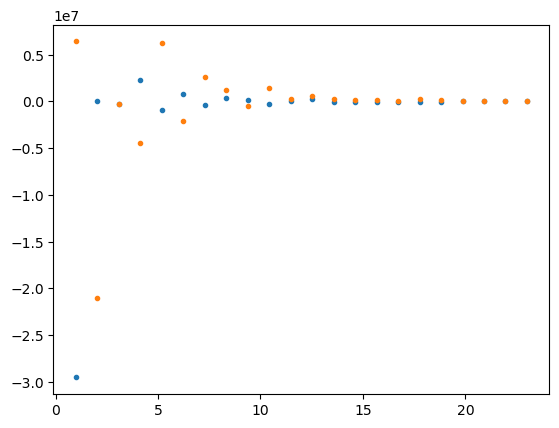

In [52]:
t = np.linspace(1,23,22)
fig, ax = plt.subplots()
ax.plot(t,arr_single[6],marker='.', ls='')
ax.plot(t,arr_single[10],marker='.', ls='')

In [22]:
dst_kpipi = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-kpipi-Q1Q2-D1/"
dst_list_kpipi = []
corr_data = []

for traj in range(1102,1233,10):
    corr_data.append(q.load_lat_data(dst_kpipi + f"traj-{traj}/K2pipi_psnk_psrc.lat").to_numpy())

kpipi_arr = np.array(corr_data)
print(kpipi_arr.shape)

(14, 9, 22)


In [23]:
kpp_jks = jackblocks_all(kpipi_arr,omit=[])

kpp_avg,kpp_err = jack_all(kpp_jks.real)

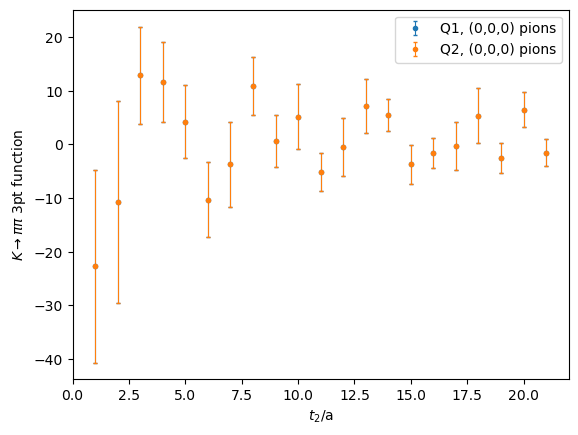

In [26]:
t = np.linspace(1,21,21)
fig,ax = plt.subplots()
ax.errorbar(t,kpp_avg[1,1:],yerr=kpp_err[1,1:],marker='.',ls='',elinewidth=0.8,capsize=1.5,label='Q1, (0,0,0) pions')
ax.errorbar(t,kpp_avg[2,1:],yerr=kpp_err[2,1:],marker='.',ls='',elinewidth=0.8,capsize=1.5,label='Q2, (0,0,0) pions')
ax.set_xlabel(r"$t_2$/a")
ax.set_ylabel(r"$K\rightarrow\pi\pi$ 3pt function")
ax.legend();

In [18]:
kpp_avg[1,:]

array([ 9.44967082, -5.2994654 , -2.49528091,  2.99903518,  2.71642719,
        0.98911786, -2.3972987 , -0.86914392,  2.5406014 ,  0.14528558,
        1.21230991, -1.19895201, -0.12088434,  1.66397863,  1.28039798,
       -0.87048171, -0.38596708, -0.06762563,  1.24757788, -0.58761729,
        1.51725282, -0.36517287])